# Decomposing Contextual Embeddings: Mechanistic Interpretability via Sparse Autoencoders

**Objective**: Train a Sparse Autoencoder (SAE) on residual stream activations from Qwen2.5-0.5B to extract interpretable, monosemantic features. Then use those features for activation steering, e.g. causally intervening in the model's forward pass to alter its generation behavior.

**Pipeline overview**:
1. **Activation Collection:** stream text through the LLM, cache intermediate activations
2. **SAE Training:** learn a sparse overcomplete dictionary with MSE + L1 loss
4. **Evaluation:** measure reconstruction quality and sparsity statistics
5. **Feature Interpretation:** find maximally activating contexts for each feature
6. **Activation Steering:** inject feature directions during generation
7. **Multi-layer Comparison:** repeat for different layers to study depth effects

In [1]:
# Install required packages
!pip install -q transformer-lens datasets clearml python-dotenv

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 15.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.6 MB/s eta 0:00:00


## 1. Imports and Configuration

In [5]:
import os
import gc
import json
import glob
import math
import random
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from transformers import AutoTokenizer
from transformer_lens import HookedTransformer
from tqdm.auto import tqdm

In [102]:
@dataclass
class Config:
    """Central configuration for all experiments."""

    # Model
    model_name: str = "Qwen/Qwen2.5-0.5B"
    dataset_name: str = "HuggingFaceFW/fineweb-edu"
    dataset_config: str = "sample-10BT"
    d_model: int = 896  # Qwen2.5-0.5B hidden size

    # SAE architecture
    expansion_factor: int = 32  # dictionary size = d_model * expansion_factor

    # Data collection
    batch_size_collect: int = 16
    seq_len: int = 512
    total_tokens: int = 2_000_000
    tokens_per_chunk: int = 200_000

    # Training hyperparameters
    batch_size_train: int = 2048
    lr: float = 1e-3
    l1_coeff: float = 3.5e-3
    l1_warmup_steps: int = 200
    seed: int = 42

    # Generation / steering
    max_new_tokens: int = 120
    temperature: float = 0.7
    top_p: float = 0.9

    # Interpretation
    num_texts: int = 500
    top_k_examples: int = 10
    activation_threshold: float = 2.0
    num_features_to_save: int = 200
    context_window: int = 5
    sink_tokens: int = 5  # first N tokens to mask (attention sink effect)

    # Directories (will be set per-layer in multi-layer experiments)
    base_dir: str = "./experiments"

    @property
    def d_sae(self) -> int:
        return self.d_model * self.expansion_factor


cfg = Config()
print(f"SAE dictionary size: {cfg.d_model} -> {cfg.d_sae} ({cfg.expansion_factor}x)")

SAE dictionary size: 896 -> 28672 (32x)


In [18]:
# Reproducibility and device management

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def get_dtype(device):
    """bfloat16 for GPU, float32 for CPU."""
    return torch.bfloat16 if device.type in ("cuda", "mps") else torch.float32


def cleanup_gpu():
    """Aggressively free GPU memory between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


set_seed(cfg.seed)
DEVICE = get_device()
DTYPE = get_dtype(DEVICE)
print(f"Device: {DEVICE} | Dtype: {DTYPE}")

Device: cuda | Dtype: torch.bfloat16


In [30]:
# Helpers for paths and ClearML

def get_layer_dirs(layer_idx: int):
    """Return (activations_dir, checkpoint_dir, artifacts_dir) for a given layer."""
    base = os.path.join(cfg.base_dir, f"layer_{layer_idx}")
    dirs = {
        "activations": os.path.join(base, "activations"),
        "checkpoints": os.path.join(base, "checkpoints"),
        "artifacts": os.path.join(base, "artifacts"),
    }
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)
    return dirs


def init_clearml(task_name: str):
    try:
        from clearml import Task, Logger

        # Kaggle stores secrets separately — inject them into env if available
        try:
            from kaggle_secrets import UserSecretsClient
            secrets = UserSecretsClient()
            for key in ["CLEARML_API_ACCESS_KEY", "CLEARML_API_SECRET_KEY",
                        "CLEARML_API_HOST", "CLEARML_WEB_HOST", "CLEARML_FILES_HOST"]:
                val = secrets.get_secret(key)
                if val:
                    os.environ[key] = val
        except Exception:
            pass  # Not on Kaggle or secrets not set

        if not os.environ.get("CLEARML_API_ACCESS_KEY"):
            print("[ClearML] No API key found — running without tracking.")
            return None, None

        task = Task.init(project_name="Mech_Interp_SAE", task_name=task_name)
        return task, Logger.current_logger()
    except ImportError:
        print("[ClearML] Package not installed — running without tracking.")
        return None, None


def hook_name_for_layer(layer_idx: int) -> str:
    """TransformerLens hook point for residual stream after a given layer."""
    return f"blocks.{layer_idx}.hook_resid_post"

## 2. Sparse Autoencoder Architecture

The SAE follows the design from Anthropic's "Towards Monosemanticity" (2023):
- **Encoder**: centers input by subtracting decoder bias, then projects to an overcomplete space with ReLU
- **Decoder**: maps sparse features back to activation space, with rows constrained to unit L2 norm
- The unit norm constraint on decoder rows prevents the model from "cheating" the L1 penalty by shrinking encoder outputs and scaling up decoder norms

In [20]:
class SparseAutoencoder(nn.Module):
    """
    Sparse Autoencoder with L1-regularized latent space.
    
    encode:  x -> ReLU((x - b_dec) @ W_enc + b_enc)
    decode:  f(x) -> f(x) @ W_dec + b_dec
    """

    def __init__(self, d_model: int, d_sae: int):
        super().__init__()
        self.d_model = d_model
        self.d_sae = d_sae

        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.W_enc = nn.Parameter(torch.empty(d_model, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_model))

        # Initialize encoder with Kaiming, decoder as its transpose
        nn.init.kaiming_uniform_(self.W_enc, a=math.sqrt(5))
        with torch.no_grad():
            self.W_dec.copy_(self.W_enc.t())
        self.normalize_decoder()

    @torch.no_grad()
    def normalize_decoder(self):
        """Project decoder rows to unit L2 norm — must be called after each optimizer step."""
        norms = self.W_dec.norm(dim=1, keepdim=True).clamp(min=1e-8)
        self.W_dec.div_(norms)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f_x):
        return f_x @ self.W_dec + self.b_dec

    def forward(self, x):
        f_x = self.encode(x)
        x_hat = self.decode(f_x)
        return x_hat, f_x


total_params = 2 * cfg.d_model * cfg.d_sae + cfg.d_model + cfg.d_sae
print(f"SAE parameters: {total_params:,}")

SAE parameters: 51,409,792


## 3. Pipeline Functions

All core pipeline stages are defined as reusable functions parameterized by `layer_idx`, so it's easy to repeat the full experiment across different layers without code duplication. Each function handles caching making the notebook safe to re-run and enabling incremental experimentation on resource-constrained environments like Kaggle.

---

**Activation Collection**

The collection function streams text from the FineWeb-Edu dataset through the frozen LLM, caching the residual stream activations at a specified layer via TransformerLens hook points. Documents are tokenized into fixed-length chunks of 512 tokens (no padding, no overlap) and processed in batches of 16. The resulting activation vectors (each of dimension 896) are accumulated in memory and periodically flushed to disk as 200K-token chunks, keeping peak RAM usage manageable even when collecting millions of tokens.

In [21]:
def tokenize_batches(dataset_iter, tokenizer, batch_size, seq_len):
    """Yield fixed-length token batches from a streaming text dataset."""
    buffer = []
    for item in dataset_iter:
        tokens = tokenizer.encode(item["text"], add_special_tokens=True)
        # Split each document into non-overlapping chunks of exactly seq_len
        for start in range(0, len(tokens) - seq_len + 1, seq_len):
            buffer.append(tokens[start : start + seq_len])
            if len(buffer) == batch_size:
                yield torch.tensor(buffer, dtype=torch.long)
                buffer = []


def collect_activations(layer_idx: int):
    """
    Stream text through the LLM and cache residual stream activations
    at the specified layer. Saves chunked .pt files to disk.
    """
    dirs = get_layer_dirs(layer_idx)
    hook = hook_name_for_layer(layer_idx)

    # Check if already collected
    existing = glob.glob(os.path.join(dirs["activations"], "chunk_*.pt"))
    if existing:
        print(f"[Layer {layer_idx}] Found {len(existing)} cached chunks — skipping collection.")
        return

    print(f"[Layer {layer_idx}] Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
    model = HookedTransformer.from_pretrained(
        cfg.model_name, device=DEVICE, dtype=DTYPE, tokenizer=tokenizer
    )
    model.eval()
    if model.tokenizer.pad_token_id is None:
        model.tokenizer.pad_token = model.tokenizer.eos_token

    dataset = load_dataset(
        cfg.dataset_name, name=cfg.dataset_config, split="train", streaming=True
    )

    buf, buf_n, total, chunk_idx = [], 0, 0, 0
    pbar = tqdm(total=cfg.total_tokens, desc=f"[Layer {layer_idx}] Collecting", unit="tok")

    for batch in tokenize_batches(iter(dataset), model.tokenizer, cfg.batch_size_collect, cfg.seq_len):
        if total >= cfg.total_tokens:
            break

        batch = batch.to(DEVICE)
        with torch.no_grad():
            _, cache = model.run_with_cache(batch, names_filter=[hook])

        # Flatten (batch, seq, d_model) -> (batch*seq, d_model) and move to CPU
        acts = cache[hook].cpu().float().reshape(-1, cfg.d_model)
        buf.append(acts)
        n = acts.shape[0]
        buf_n += n
        total += n
        pbar.update(n)

        del cache
        model.reset_hooks()

        # Save chunk when buffer is full
        if buf_n >= cfg.tokens_per_chunk:
            combined = torch.cat(buf, dim=0)
            chunk = combined[: cfg.tokens_per_chunk]
            remainder = combined[cfg.tokens_per_chunk :]

            path = os.path.join(dirs["activations"], f"chunk_{chunk_idx}.pt")
            torch.save(chunk, path)
            print(f"\n  Saved {path} — shape {chunk.shape}")

            buf = [remainder] if remainder.shape[0] > 0 else []
            buf_n = remainder.shape[0]
            chunk_idx += 1

    pbar.close()

    # Save leftover
    if buf_n > 0:
        chunk = torch.cat(buf, dim=0)
        path = os.path.join(dirs["activations"], f"chunk_{chunk_idx}.pt")
        torch.save(chunk, path)
        print(f"  Saved final {path} — shape {chunk.shape}")
        chunk_idx += 1

    print(f"[Layer {layer_idx}] Done: {total:,} tokens in {chunk_idx} chunk(s).")

    del model
    cleanup_gpu()

---

**SAE Training**

The training function iterates over all cached activation chunks, optimizing the SAE with a combined loss: MSE reconstruction loss plus an L1 penalty on the latent activations weighted by a coefficient that linearly warms up over the first 200 steps. The warmup prevents early training collapse where the L1 term dominates before the encoder has learned useful directions, which would push all features to zero and create a large number of permanently dead neurons. After each optimizer step, the decoder weight rows are re-normalized to unit L2 norm to maintain the constraint described in Section 2. Training metrics (total loss, FVE, L0 sparsity, and dead feature percentage) are logged every 10 steps for later visualization.

In [100]:
def get_l1_coeff(step):
    """Linear warmup for L1 regularization coefficient."""
    if cfg.l1_warmup_steps <= 0 or step >= cfg.l1_warmup_steps:
        return cfg.l1_coeff
    return cfg.l1_coeff * (step / cfg.l1_warmup_steps)


def compute_fve(x, x_hat):
    """Fraction of Variance Explained — 1.0 is perfect, 0.0 is mean baseline."""
    total_var = x.var(dim=0, unbiased=False).sum()
    mse = (x - x_hat).pow(2).mean(dim=0).sum()
    return (1.0 - mse / total_var).item() if total_var.item() > 1e-10 else 0.0


def train_sae(layer_idx: int):
    """
    Train the SAE on cached activations for a given layer.
    Returns training history dict and the path to the final checkpoint.
    """
    dirs = get_layer_dirs(layer_idx)
    final_path = os.path.join(dirs["checkpoints"], "sae_final.pt")

    # Skip if already trained
    if os.path.isfile(final_path):
        print(f"[Layer {layer_idx}] Found trained SAE - skipping training.")
        return None, final_path

    task, logger = init_clearml(f"SAE_Train_Layer_{layer_idx}")

    chunk_files = sorted(glob.glob(os.path.join(dirs["activations"], "chunk_*.pt")))
    assert chunk_files, f"No activation chunks found for layer {layer_idx}!"

    sae = SparseAutoencoder(cfg.d_model, cfg.d_sae).to(DEVICE)
    optimizer = Adam(sae.parameters(), lr=cfg.lr)

    global_step = 0
    history = {"loss": [], "mse": [], "l0": [], "fve": [], "dead_pct": []}

    for ci, cf in enumerate(chunk_files):
        print(f"\n[Layer {layer_idx}] Chunk {ci+1}/{len(chunk_files)}: {os.path.basename(cf)}")
        data = torch.load(cf, map_location="cpu", weights_only=True)
        loader = DataLoader(
            TensorDataset(data), batch_size=cfg.batch_size_train,
            shuffle=True, pin_memory=(DEVICE.type == "cuda"), drop_last=True,
        )

        pbar = tqdm(loader, desc=f"  Training chunk {ci+1}")
        for (x_batch,) in pbar:
            x = x_batch.to(DEVICE)
            x_hat, f_x = sae(x)

            mse_loss = nn.functional.mse_loss(x_hat, x)
            l1_lambda = get_l1_coeff(global_step)
            l1_loss = f_x.abs().sum(dim=-1).mean()
            loss = mse_loss + l1_lambda * l1_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            sae.normalize_decoder()

            # Monitoring metrics (no grad needed)
            with torch.no_grad():
                l0 = (f_x > 0).float().sum(dim=-1).mean().item()
                fve = compute_fve(x, x_hat)
                dead = (f_x.sum(dim=0) == 0).sum().item()
                dead_pct = 100.0 * dead / cfg.d_sae

            pbar.set_postfix(
                Loss=f"{loss.item():.4f}", L0=f"{l0:.0f}",
                FVE=f"{fve:.3f}", Dead=f"{dead_pct:.1f}%"
            )

            if logger:
                logger.report_scalar("Loss", "Total", iteration=global_step, value=loss.item())
                logger.report_scalar("Loss", "MSE", iteration=global_step, value=mse_loss.item())
                logger.report_scalar("Sparsity", "L0", iteration=global_step, value=l0)
                logger.report_scalar("Quality", "FVE", iteration=global_step, value=fve)
                logger.report_scalar("Sparsity", "Dead%", iteration=global_step, value=dead_pct)

            if global_step % 10 == 0:
                history["loss"].append(loss.item())
                history["mse"].append(mse_loss.item())
                history["l0"].append(l0)
                history["fve"].append(fve)
                history["dead_pct"].append(dead_pct)

            global_step += 1

        # Checkpoint after each chunk
        torch.save(sae.state_dict(), os.path.join(dirs["checkpoints"], f"sae_chunk_{ci+1}.pt"))

    torch.save(sae.state_dict(), final_path)
    print(f"\n[Layer {layer_idx}] Training done in {global_step:,} steps. Saved to {final_path}")

    if task:
        task.close()

    del sae, optimizer
    cleanup_gpu()

    return history, final_path

---

**Evaluation**

The evaluation function computes aggregate reconstruction and sparsity metrics over the entire activation dataset in a single forward pass through the trained SAE. It reports mean MSE, Fraction of Variance Explained (FVE), mean L0 norm (average number of active features per token), and the count of dead features (latent dimensions that never activate across the full dataset). These metrics collectively assess whether the SAE has found a good trade-off between faithful reconstruction and sparsity: high FVE with low L0 indicates that a small number of features suffice to capture most of the variance in the residual stream.

In [23]:
def evaluate_sae(layer_idx: int):
    """
    Compute aggregate reconstruction and sparsity metrics
    over all cached activations for the given layer.
    """
    dirs = get_layer_dirs(layer_idx)
    ckpt_path = os.path.join(dirs["checkpoints"], "sae_final.pt")

    sae = SparseAutoencoder(cfg.d_model, cfg.d_sae).to(DEVICE)
    sae.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    sae.eval()

    chunk_files = sorted(glob.glob(os.path.join(dirs["activations"], "chunk_*.pt")))

    total_mse, total_var, total_l0, total_n = 0.0, 0.0, 0.0, 0
    feat_counts = torch.zeros(cfg.d_sae, device=DEVICE)

    for cf in tqdm(chunk_files, desc=f"[Layer {layer_idx}] Evaluating"):
        data = torch.load(cf, map_location="cpu", weights_only=True)
        loader = DataLoader(TensorDataset(data), batch_size=cfg.batch_size_train)

        for (x_batch,) in loader:
            x = x_batch.to(DEVICE)
            with torch.no_grad():
                x_hat, f_x = sae(x)
                n = x.shape[0]
                total_mse += (x - x_hat).pow(2).sum().item()
                total_var += x.var(dim=0, unbiased=False).sum().item() * n
                total_l0 += (f_x > 0).float().sum().item()
                total_n += n
                feat_counts += (f_x > 0).float().sum(dim=0)

    fve = 1.0 - (total_mse / total_n) / (total_var / total_n) if total_var > 0 else 0.0
    mean_l0 = total_l0 / total_n
    dead = (feat_counts == 0).sum().item()
    alive_counts = feat_counts[feat_counts > 0]

    report = {
        "layer": layer_idx,
        "tokens_evaluated": total_n,
        "mean_mse": total_mse / (total_n * cfg.d_model),
        "fve": fve,
        "mean_l0": mean_l0,
        "dead_features": dead,
        "dead_pct": round(100.0 * dead / cfg.d_sae, 2),
        "alive_features": cfg.d_sae - dead,
        "median_feat_freq": alive_counts.median().item() if len(alive_counts) > 0 else 0,
    }

    print(f"\nEvaluation Report (Layer {layer_idx})")
    for k, v in report.items():
        if isinstance(v, float):
            print(f"  {k:25s}: {v:.6f}")
        else:
            print(f"  {k:25s}: {v}")

    # Save report
    path = os.path.join(dirs["artifacts"], "evaluation_report.json")
    with open(path, "w") as f:
        json.dump(report, f, indent=2)

    del sae
    cleanup_gpu()

    return report

---

**Feature Interpretation**

The interpretation function builds a human-readable dictionary mapping each SAE feature to its maximally activating text contexts. For each of 500 text samples, it runs the LLM to obtain residual stream activations, encodes them through the SAE, and records which features fire most strongly and at which token positions. The first few token positions are masked to avoid attention sink artifacts, because early positions in autoregressive models tend to accumulate disproportionately high activations regardless of content. Each feature's top-k examples are saved with the activating token highlighted in its surrounding context window, enabling qualitative assessment of whether the feature is monosemantic (consistently firing on a single coherent concept).

In [24]:
def build_feature_dictionary(layer_idx: int):
    """
    Find maximally activating text contexts for each SAE feature.
    Produces a JSON artifact mapping feature IDs to their top examples.
    """
    dirs = get_layer_dirs(layer_idx)
    hook = hook_name_for_layer(layer_idx)
    dict_path = os.path.join(dirs["artifacts"], "feature_dictionary.json")

    # Skip if already built
    if os.path.isfile(dict_path):
        print(f"[Layer {layer_idx}] Loading existing feature dictionary.")
        with open(dict_path) as f:
            return json.load(f)

    print(f"[Layer {layer_idx}] Building feature dictionary...")
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
    llm = HookedTransformer.from_pretrained(
        cfg.model_name, device=DEVICE, dtype=DTYPE, tokenizer=tokenizer
    )
    llm.eval()

    sae = SparseAutoencoder(cfg.d_model, cfg.d_sae).to(DEVICE)
    ckpt = os.path.join(dirs["checkpoints"], "sae_final.pt")
    sae.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    sae.eval()

    # Grab text samples from the dataset
    dataset = load_dataset(cfg.dataset_name, name=cfg.dataset_config, split="train", streaming=True)
    texts = [item["text"][:1000] for _, item in zip(range(cfg.num_texts), dataset)]

    feature_acts = {}

    for text in tqdm(texts, desc=f"  Analyzing texts"):
        tokens = llm.tokenizer.encode(text, return_tensors="pt").to(DEVICE)
        if tokens.shape[1] < cfg.sink_tokens + 2:
            continue

        with torch.no_grad():
            _, cache = llm.run_with_cache(tokens, names_filter=[hook])
            f_x = sae.encode(cache[hook][0].float())
            # Zero out attention sink positions — they have anomalously high activations
            f_x[: cfg.sink_tokens, :] = 0.0
            max_vals, max_pos = f_x.max(dim=0)

        active_feats = (max_vals > cfg.activation_threshold).nonzero(as_tuple=True)[0]
        tok_ids = tokens[0].cpu()

        for feat in active_feats.tolist():
            val = max_vals[feat].item()
            pos = max_pos[feat].item()

            # Extract context window around the max-activating position
            start = max(0, pos - cfg.context_window)
            end = min(len(tok_ids), pos + cfg.context_window + 1)
            target = llm.tokenizer.decode([tok_ids[pos].item()])
            context = llm.tokenizer.decode(tok_ids[start:end].tolist())
            highlighted = context.replace(
                target, f" >>>{target.strip()}<<< ", 1
            ).replace("\n", " ").strip()

            if feat not in feature_acts:
                feature_acts[feat] = []
            feature_acts[feat].append({
                "score": round(val, 3),
                "target": target.strip(),
                "context": highlighted,
            })

        del cache
        llm.reset_hooks()

    # Sort features by their strongest activation and keep top N
    sorted_feats = sorted(
        feature_acts.items(),
        key=lambda x: max(e["score"] for e in x[1]),
        reverse=True,
    )
    dictionary = {}
    for feat_id, examples in sorted_feats[: cfg.num_features_to_save]:
        examples.sort(key=lambda x: x["score"], reverse=True)
        dictionary[str(feat_id)] = examples[: cfg.top_k_examples]

    with open(dict_path, "w", encoding="utf-8") as f:
        json.dump(dictionary, f, indent=2, ensure_ascii=False)
    print(f"  Saved {dict_path} — {len(dictionary)} features")

    del llm, sae
    cleanup_gpu()

    return dictionary

---

**Feature Display Utility**

A simple helper that pretty-prints the top activating examples for a given feature ID from the precomputed dictionary, showing the activation score and the highlighted context window around the maximally activating token.

In [25]:
def show_feature(dictionary, feature_id, n=5):
    """Print top activating examples for a given feature."""
    key = str(feature_id)
    if key not in dictionary:
        print(f"Feature {key} not found in dictionary.")
        return
    examples = dictionary[key][:n]
    print(f"Feature #{key} ({len(dictionary[key])} examples total):")
    for ex in examples:
        print(f"  [{ex['score']:6.2f}] {ex['context']}")
    print()

---

**Activation Steering**

Activation steering tests whether learned SAE features are **causally meaningful** rather than mere correlational artifacts. The approach is straightforward: during the LLM's forward pass, add a scaled version of a feature's decoder direction vector (the corresponding row of W_dec) to the residual stream at the layer where the feature was extracted. Positive scaling (α > 0) amplifies the concept, negative scaling (α < 0) suppresses it. By comparing steered generation against an unmodified baseline it is possible to assess whether the feature genuinely controls a recognizable aspect of model behavior.

In [26]:
def load_llm_and_sae(layer_idx: int):
    """Load the LLM and trained SAE for a given layer."""
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
    llm = HookedTransformer.from_pretrained(
        cfg.model_name, device=DEVICE, dtype=DTYPE, tokenizer=tokenizer
    )
    llm.eval()

    sae = SparseAutoencoder(cfg.d_model, cfg.d_sae).to(DEVICE)
    ckpt = os.path.join(get_layer_dirs(layer_idx)["checkpoints"], "sae_final.pt")
    sae.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    sae.eval()

    return llm, sae


def compute_perplexity(model, text, hooks=None):
    """Compute perplexity of text, optionally under forward hooks."""
    tokens = model.tokenizer.encode(text, return_tensors="pt").to(DEVICE)
    if hooks:
        with model.hooks(fwd_hooks=hooks):
            with torch.no_grad():
                loss = model(tokens, return_type="loss")
    else:
        with torch.no_grad():
            loss = model(tokens, return_type="loss")
    return torch.exp(loss).item()


def steer_experiment(llm, sae, layer_idx, feature_id, alpha, prompt, logger=None):
    """
    Run one steering experiment: generate text with and without
    injecting a feature direction into the residual stream.
    
    Positive alpha amplifies the feature, negative alpha suppresses it.
    """
    hook = hook_name_for_layer(layer_idx)

    # Get the feature direction vector (decoder row) and cast to model dtype
    steering_vec = sae.W_dec[feature_id].detach().clone().to(device=DEVICE, dtype=DTYPE)

    def hook_fn(resid_post, hook):
        return resid_post + alpha * steering_vec

    hook_pair = [(hook, hook_fn)]

    # Baseline generation (no intervention)
    baseline_text = llm.generate(
        prompt, max_new_tokens=cfg.max_new_tokens,
        temperature=cfg.temperature, top_p=cfg.top_p,
        use_past_kv_cache=False,
    )
    baseline_ppl = compute_perplexity(llm, baseline_text)

    # Steered generation (feature injected)
    with llm.hooks(fwd_hooks=hook_pair):
        steered_text = llm.generate(
            prompt, max_new_tokens=cfg.max_new_tokens,
            temperature=cfg.temperature, top_p=cfg.top_p,
            use_past_kv_cache=False,
        )
    steered_ppl = compute_perplexity(llm, steered_text, hooks=hook_pair)

    result = {
        "layer": layer_idx,
        "feature_id": feature_id,
        "alpha": alpha,
        "prompt": prompt,
        "baseline_text": baseline_text,
        "steered_text": steered_text,
        "baseline_ppl": round(baseline_ppl, 2),
        "steered_ppl": round(steered_ppl, 2),
        "ppl_shift": round(steered_ppl - baseline_ppl, 2),
    }

    # Display results
    direction = "positive" if alpha > 0 else "negative"
    print(f"\n{'='*70}")
    print(f"Layer {layer_idx} | Feature #{feature_id} | α={alpha} ({direction} steering)")
    print(f"{'='*70}")
    print(f"\nBASELINE (PPL: {result['baseline_ppl']}):")
    print(f"  {baseline_text}")
    print(f"\nSTEERED (PPL: {result['steered_ppl']}, shift: {result['ppl_shift']:+.2f}):")
    print(f"  {steered_text}")

    # Log to ClearML if available
    if logger:
        tag = f"L{layer_idx}_F{feature_id}_a{alpha}"
        logger.report_single_value(f"{tag}/baseline_ppl", baseline_ppl)
        logger.report_single_value(f"{tag}/steered_ppl", steered_ppl)
        logger.report_text(f"[{tag}]\nBaseline:\n{baseline_text}\n\nSteered:\n{steered_text}")

    return result

## 4. Run Full Pipeline for the Primary Layer (Layer 12)

Let's start with layer 12 (middle of the 24-layer Qwen2.5-0.5b model). This is where it is expected the richest semantic representations, as soon as early layers capture syntax, late layers capture output-specific features, and middle layers tend to hold the most interpretable concepts.

---

**Stage 1: Collect activations**

In [27]:
PRIMARY_LAYER = 12

collect_activations(PRIMARY_LAYER)

[Layer 12] Loading model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

[Layer 12] Collecting:   0%|          | 0/2000000 [00:00<?, ?tok/s]


  Saved ./experiments/layer_12/activations/chunk_0.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_1.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_2.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_3.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_4.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_5.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_6.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_7.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_8.pt — shape torch.Size([200000, 896])

  Saved ./experiments/layer_12/activations/chunk_9.pt — shape torch.Size([200000, 896])
  Saved final ./experiments/layer_12/activations/chunk_10.pt — shape torch.Size([7040, 896])
[Layer 12] Done: 

---

**Stage 2: Train SAE**

The train_sae function returns the training history and the path the model's checkpoint

In [28]:
train_history_12, ckpt_path_12 = train_sae(PRIMARY_LAYER)

[ClearML] No API key found — running without tracking.

[Layer 12] Chunk 1/11: chunk_0.pt


  Training chunk 1:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 12] Chunk 2/11: chunk_1.pt


  Training chunk 2:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 12] Chunk 3/11: chunk_10.pt


...


[Layer 12] Chunk 10/11: chunk_8.pt


  Training chunk 10:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 12] Chunk 11/11: chunk_9.pt


  Training chunk 11:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 12] Training done in 973 steps. Saved to ./experiments/layer_12/checkpoints/sae_final.pt


---

**Visualize SAE Learning Curves**

The visualization includes the loss function, fraction of explained variance, L0 sparsity, and percentage of dead features during SAE training.

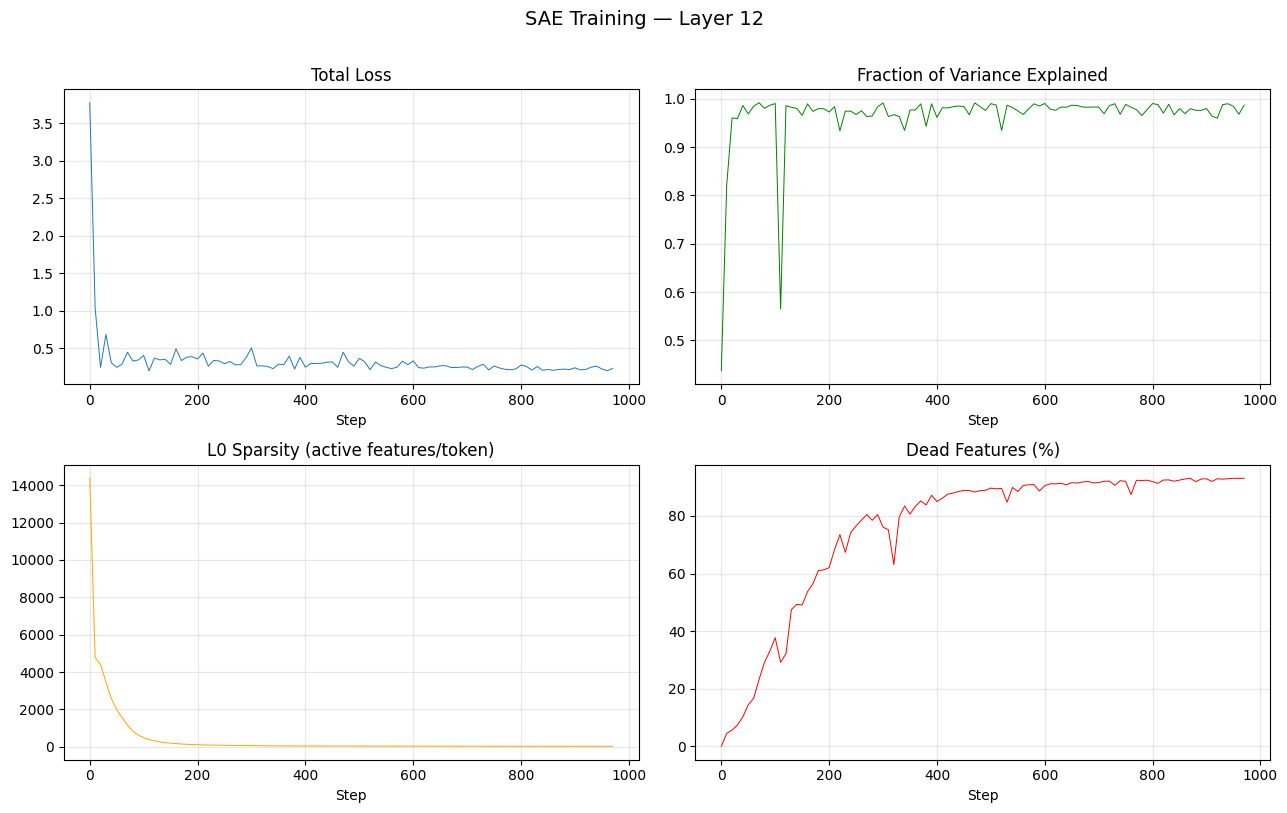

Saved to ./experiments/layer_12/artifacts/training_curves.png


In [31]:
if train_history_12:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    steps = [i * 10 for i in range(len(train_history_12["loss"]))]

    axes[0, 0].plot(steps, train_history_12["loss"], lw=0.7)
    axes[0, 0].set(title="Total Loss", xlabel="Step")

    axes[0, 1].plot(steps, train_history_12["fve"], lw=0.7, color="green")
    axes[0, 1].set(title="Fraction of Variance Explained", xlabel="Step")

    axes[1, 0].plot(steps, train_history_12["l0"], lw=0.7, color="orange")
    axes[1, 0].set(title="L0 Sparsity (active features/token)", xlabel="Step")

    axes[1, 1].plot(steps, train_history_12["dead_pct"], lw=0.7, color="red")
    axes[1, 1].set(title="Dead Features (%)", xlabel="Step")

    for ax in axes.flat:
        ax.grid(True, alpha=0.3)

    plt.suptitle("SAE Training — Layer 12", fontsize=14, y=1.01)
    plt.tight_layout()

    plot_path = os.path.join(get_layer_dirs(PRIMARY_LAYER)["artifacts"], "training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {plot_path}")
else:
    print("Loaded from checkpoint — no training history to plot.")

---

**Stage 3: Quantitative evaluation of the final SAE model**

In [32]:
eval_report_12 = evaluate_sae(PRIMARY_LAYER)

[Layer 12] Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]


Evaluation Report (Layer 12)
  layer                    : 12
  tokens_evaluated         : 2007040
  mean_mse                 : 0.111182
  fve                      : 0.983118
  mean_l0                  : 26.582463
  dead_features            : 13550
  dead_pct                 : 47.260000
  alive_features           : 15122
  median_feat_freq         : 5.000000


---

**Stage 4: Feature interpretation**

Find the most activating monosemantic features on the text samples.

In [33]:
feat_dict_12 = build_feature_dictionary(PRIMARY_LAYER)

[Layer 12] Building feature dictionary...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  Analyzing texts:   0%|          | 0/500 [00:00<?, ?it/s]

  Saved ./experiments/layer_12/artifacts/feature_dictionary.json — 200 features


### Inspecting Top Features

Each feature should activate on semantically coherent contexts. If a feature consistently fires on, say, mathematical terms or biological concepts or some symbols, that's evidence of monosemanticity.

In [84]:
top_feats_12 = list(feat_dict_12.keys())[:20]
# Let's take a look on the 20 top activating features
for fid in top_feats_12[:20]:
    show_feature(feat_dict_12, fid)

Feature #24484 (2 examples total):
  [ 13.99] Trisurat (email >>>@example<<< .com). Context. Assess
  [ 11.84] ; e-mail firstname.lastname >>>@example<<< .org. Avataric evolution

Feature #16902 (10 examples total):
  [ 13.23] granted as professional scientists. >>>Even<<<  simple geographic and cartographic
  [ 13.21] used in the construction. >>>Even<<<  after many centuries of wear
  [ 12.78] of new cases.1 >>>Even<<<  when diabetes is controlled,
  [ 12.57] stage of life, and >>>even<<<  into death (e.g
  [ 12.33] in an emergency. And >>>even<<<  though power outages may

Feature #22761 (10 examples total):
  [ 12.11] 1 >>>0<<< 0,000 times faster than
  [ 11.93] 25 >>>0<<< ,000-square-foot,
  [ 11.89] 5 >>>0<<< 0,000 new human cases
  [ 11.77] 1 >>>0<<< 0,000 people are diagnosed
  [ 11.43] 45 >>>0<<< ,000 servers. "

Feature #20105 (10 examples total):
  [ 11.81] 28 wavelength bands. >>>This<<<  allows for the discrimination of
  [ 11.71] and they communicate differently. >>>This<

## 5. Activation Steering Experiments (Layer 12)

Test whether the features are **causally meaningful** by injecting them into the residual stream during generation. If a feature truly represents a concept, amplifying it (positive α) should push generation toward that concept, and suppressing it (negative α) should push generation away.

---

**Initialize ClearML tasks and load LLM & SAE**

In [37]:
task, logger = init_clearml("Steering_Experiments")
llm, sae = load_llm_and_sae(PRIMARY_LAYER)

ClearML Task: created new task id=d1d8b98c59804036a8c4fd1edc9515fe


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-04-20 19:07:17,913 - clearml.Repository Detection - WARNING - Jupyter Notebook auto-logging failed, could not access: /kaggle/working/__notebook_source__.ipynb
2026-04-20 19:07:17,939 - clearml.Task - INFO - Storing jupyter notebook directly as code


2026-04-20 19:07:20.323805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776712040.552556      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776712040.622169      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776712041.174163      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776712041.174189      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776712041.174192      55 computation_placer.cc:177] computation placer alr

ClearML results page: https://app.clear.ml/projects/72070af41ad34a8086e7374e3748e077/experiments/d1d8b98c59804036a8c4fd1edc9515fe/output/log


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


---

**Steer the feature 21836 (formal report)**

Let's look on the examples, where the feature 21836 activates:

- "...Nowadays. 45 >>>%<<<  of working Australians are women..."

- "...accounting for 18 >>>%<<<  of global output. Energy..."

There is a persistent feeling that this features is responsible for marking numerical percentage facts and statements.

Let's experiment with this feature. First, steer the model on **positive direction** along the feature.

In [56]:
feature_report = 21836
show_feature(feat_dict_12, feature_report)

# Get the steered result on positive impact (alpha > 0)
result_pos_1 = steer_experiment(
    llm, sae, PRIMARY_LAYER,
    feature_id=feature_report,
    alpha=8.0,
    prompt="Can you tell me about what is life? Yes, life is",
    logger=logger,
)

Feature #21836 (10 examples total):
  [ 11.74] Nowadays. 45 >>>%<<<  of working Australians are women
  [ 11.49] accounting for 18 >>>%<<<  of global output. Energy
  [ 11.31] . About 40 >>>%<<<  of the children in the
  [ 11.26] for nearly 44 >>>percent<<<  of new cases.1
  [ 11.18] cities. Eighty six >>>percent<<<  of families own either one



  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


Layer 12 | Feature #21836 | α=8.0 (positive steering)

BASELINE (PPL: 2.58):
  Can you tell me about what is life? Yes, life is a complex and multifaceted phenomenon that encompasses the physical, biological, and psychological aspects of human existence. It is a continuous cycle of birth, growth, and aging, which shapes our personalities, beliefs, and relationships with others. Life also involves the exploration of the world around us, the pursuit of knowledge and understanding, and the development of personal goals and aspirations. Ultimately, life is a journey that takes us through a series of experiences and relationships, ultimately leading to a sense of fulfillment and meaning.

STEERED (PPL: 2.58, shift: +0.00):
  Can you tell me about what is life? Yes, life is a complex and dynamic process of human experience, influenced by genetic, environmental, and social factors, and influenced by individual differences. It is also influenced by external factors, such as socioeconomic stat

Actually, the model is successfully steered towards **feature 21836**, but the real meaning of the feature is **'Considering factors, give facts and statements'** and the feature styles the text to **formal report**.

The model turns the conversation to discussing the percentage of people who experience happiness.

Now, let's steer on **negative direction**

In [57]:
# Negative steering with the same feature
result_neg_1 = steer_experiment(
    llm, sae, PRIMARY_LAYER,
    feature_id=feature_report,
    alpha=-8.0,
    prompt="Can you tell me about what is life? Yes, life is",
    logger=logger,
)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


Layer 12 | Feature #21836 | α=-8.0 (negative steering)

BASELINE (PPL: 2.64):
  Can you tell me about what is life? Yes, life is a continuous cycle of birth, growth, aging, death, and rebirth. It is a complex and intricate process that involves many interconnected factors, including genetics, environment, and social factors. Life is not static, but rather constantly evolving, and it is influenced by various external and internal factors. The cycle of life is also marked by ups and downs, as well as periods of peace and stability. Overall, life is a beautiful and dynamic process that is characterized by its unique qualities and characteristics.

Can you give me an example of how the cycle of life is affected by genetics? Sure, genetics play a significant role in shaping our life cycle. The genes we inherit from our parents can influence various aspects of our physical, mental, and emotional health.

STEERED (PPL: 2.8, shift: +0.16):
  Can you tell me about what is life? Yes, life is a 

Now, the text is definitely not a formal report and there are no consideration of factors. I think that model successfully steered from the feature 21836.

**Steer the feature 3338 (Citation style)**

The feature persistently activates on the citations in the text, examples:

- "...early predictors of later success >>>,”<<<  said Megan McClelland..."

- "...we've tended to imagine >>>,"<<<  says study co-author T..."

From the examples one can make the conclusion that the feature activates on **citations**, let's check.

In [71]:
# Take the feature
feature_citation = 3338
show_feature(feat_dict_12, feature_citation)
# Steer in positive direction
result_pos_2 = steer_experiment(
    llm, sae, PRIMARY_LAYER,
    feature_id=feature_citation,
    alpha=8.0,
    prompt="Can you tell me how the music affects poeple feeling in details? Yes,",
    logger=logger,
)

Feature #3338 (10 examples total):
  [ 11.35] early predictors of later success >>>,”<<<  said Megan McClelland
  [ 11.14] we've tended to imagine >>>,"<<<  says study co-author T
  [ 11.13] increases the motivation to exercise >>>,"<<<  said Max Gass
  [ 11.06] pathologies and memory deficits >>>,"<<<  said William Bowers,
  [ 11.05] airways by multiple bacteria >>>,"<<<  said study co-author Homer



  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


Layer 12 | Feature #3338 | α=8.0 (positive steering)

BASELINE (PPL: 2.88):
  Can you tell me how the music affects poeple feeling in details? Yes, of course. The music can have a profound effect on people's emotions and feelings. It can create a sense of relaxation, calmness, or even a sense of excitement, depending on the type of music being played. It can also evoke memories and emotions, bringing back feelings of nostalgia or nostalgia for a past event. Music can also be used to create a sense of mood and atmosphere, which can be used to create a sense of unity or connection between people. Additionally, music can be used to create a sense of harmony or contrast, which can be used to create a sense of balance or order in a group or setting.

Can you give me an example of a specific type of music that can have such a profound effect on people? Yes,

STEERED (PPL: 3.06, shift: +0.19):
  Can you tell me how the music affects poeple feeling in details? Yes, I can provide a general res

The feauture, indeed, affects the model behaviour toward third-party authority citation and pseudo-journalistic sourcing

In [72]:
# Steer in negative direction
result_neg_2 = steer_experiment(
    llm, sae, PRIMARY_LAYER,
    feature_id=feature_citation,
    alpha=-8.0,
    prompt="Can you tell me how the music affects poeple feeling in details? Yes,",
    logger=logger,
)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


Layer 12 | Feature #3338 | α=-8.0 (negative steering)

BASELINE (PPL: 2.48):
  Can you tell me how the music affects poeple feeling in details? Yes, certainly. Music can have a profound impact on people's emotions, thoughts, and behavior. Here are some ways in which music affects people:

1. Mood: Music can evoke a wide range of emotions, from happiness and joy to sadness and anger. It can create a sense of calmness, relaxation, or excitement, depending on the music.

2. Memory: Music can help people remember important information or facts. For example, a song about a historical event can help people remember that event.

3. Stress reduction: Music can be a powerful tool for reducing stress and anxiety. Listening to calming music can help people feel more relaxed and comfortable.

4. Mood boost: Music can also have a positive effect on mood. Listening to upbeat music can increase

STEERED (PPL: 3.3, shift: +0.81):
  Can you tell me how the music affects poeple feeling in details? Yes,

It's not clear how the **negative** steering from the **citation style feature** affects the model, but at least there are no citatons in text)

### Alpha Sweep

How does generation quality degrade as we increase the intervention strength? Let's test a range of α values (both positive and negative) for a single feature to observe the trade-off between behavioral change and coherence.

The this experiment, let's try the citation style feature.

In [86]:
# take the citation style feature
sweep_feature = 3338
# define all the steering coefficients
alphas = [-10.0, -7.5, -5.0, 5.0, 7.5, 10.0]
# define initial prompt
sweep_prompt = "Now, let's talk about clothes and how to style the outfit for date night."

sweep_results = []

for a in alphas:
    if a == 0.0:
        # Baseline with no steering
        text = llm.generate(
            sweep_prompt, max_new_tokens=cfg.max_new_tokens,
            temperature=cfg.temperature, top_p=cfg.top_p,
            use_past_kv_cache=False,
        )
        ppl = compute_perplexity(llm, text)
        sweep_results.append({"alpha": a, "ppl": round(ppl, 2), "text": text})
        print(f"α={a:+6.1f} | PPL={ppl:8.2f} | {text[:100]}...")
    else:
        r = steer_experiment(llm, sae, PRIMARY_LAYER, sweep_feature, a, sweep_prompt, logger)
        sweep_results.append({"alpha": a, "ppl": r["steered_ppl"], "text": r["steered_text"]})

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #3338 | α=-10.0 (negative steering)

BASELINE (PPL: 3.78):
  Now, let's talk about clothes and how to style the outfit for date night. I'm going to make a white top with a black shirt, a pair of black jeans, and a black leather jacket. The top and bottom are white, and the shirt and jeans are black. The leather jacket is a black leather jacket. 

To style this outfit for date night, I would recommend wearing a black t-shirt with a black tank top. This will complete the outfit and give it a sophisticated look. To add a touch of glamour, I would pair the top with a black leather jacket and a black tie. The black leather jacket will give the outfit a touch of sophistication, and

STEERED (PPL: 2.55, shift: -1.23):
  Now, let's talk about clothes and how to style the outfit for date night. We'll be discussing the following questions:

1. What is a Date Night?
2. What is the date night for? 3. Date Night? 4. What is a Date Night? 5. What is a Date Night? 6. What is a Dat

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #3338 | α=7.5 (positive steering)

BASELINE (PPL: 4.06):
  Now, let's talk about clothes and how to style the outfit for date night. I know that a dress is the most classic and elegant choice, but I want to try something more casual and fun. Can you help me come up with some ideas for outfits that would be perfect for date night? Absolutely! Here are some outfit ideas that would be perfect for date night:

1. Party dress - A simple dress with a plunging neckline, a sweetheart neckline, or a slit dress can work well for date night. It's the perfect way to show off your femininity and be ready to dance all night long.

2. White shirt and skinny jeans - A white shirt and skinny

STEERED (PPL: 3.75, shift: -0.31):
  Now, let's talk about clothes and how to style the outfit for date night. Sara says, "I love the way he looks. I think he's going to love it." says Andrea.
"I love his look," says Sara.
"Am I right?" says Andrea.
"Am I right?" says Andrea.
"Am I right?" says

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #3338 | α=10.0 (positive steering)

BASELINE (PPL: 3.8):
  Now, let's talk about clothes and how to style the outfit for date night. First, we should choose a dress that is comfortable and not too tight. For women, opt for a dress that has a bell shape or a fitted dress. For men, a button-up shirt and a tie or bow tie are good choices. For a night out, it's best to wear a dress or a dress with a blouse. For a dress with a blouse, you can also pair it with a tie or bow tie. For a dress with a skirt, you can pair it with a jacket or a shirt. For a dress with a skirt, you can also pair it with a skirt

STEERED (PPL: 7.28, shift: +3.48):
  Now, let's talk about clothes and how to style the outfit for date night. says Mr. Thomas. says David, a graduate student in the Department of Fashion Design. says the program he leads. says Thomas says the fashion designer and the program's director says he is excited to be speaking with David.
Thomas says, "And he said it's David, t

**Analysis:** The feature that is analysed is responsible for citation style. As the steering coefficient is larger by module, the higher the probability of the model degradation that's visible, when alpha equal to -10, 10, and partially 7.5. The model tends to add citations, when the coefficient is positive and use direct speech, when the coefficient is negative.

---

**Take a look on effect of steering strength on perplexity**

/usr/local/lib/python3.12/dist-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



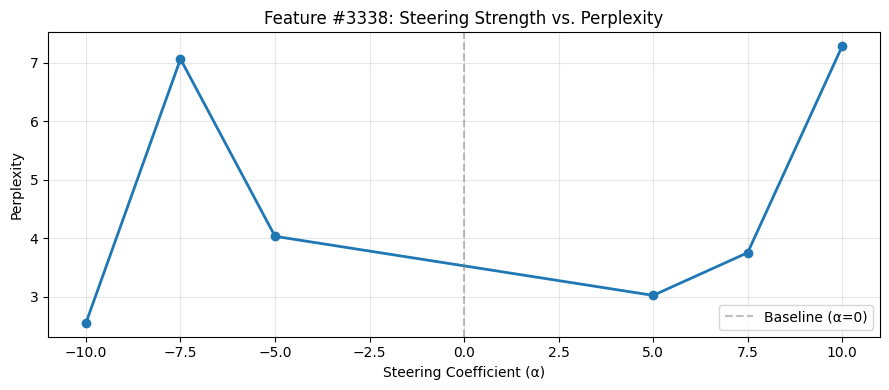

In [87]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
alphas_plot = [r["alpha"] for r in sweep_results]
ppls_plot = [r["ppl"] for r in sweep_results]

ax.plot(alphas_plot, ppls_plot, "o-", linewidth=2, markersize=6)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5, label="Baseline (α=0)")
ax.set_xlabel("Steering Coefficient (α)")
ax.set_ylabel("Perplexity")
ax.set_title(f"Feature #{sweep_feature}: Steering Strength vs. Perplexity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

path = os.path.join(get_layer_dirs(PRIMARY_LAYER)["artifacts"], "alpha_sweep.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

In [98]:
# Free all steering models before running other layers
del llm, sae
if task:
    task.close()
    task = None
    logger = None
cleanup_gpu()
print("GPU memory released.")

GPU memory released.


In [ ]:
import shutil

# Free disk
acts_dir = get_layer_dirs(12)["activations"]
if os.path.exists(acts_dir):
    shutil.rmtree(acts_dir)
    print(f"Deleted {acts_dir}")

## 6. Multi-Layer Comparison

Repeat the full pipeline for two additional layers to study how features change across model depth:

| Layer | Position | Expected behavior |
|-------|----------|-------------------|
| **6** | Early (25%) | More syntactic/positional features |
| **12** | Middle (50%) | Rich semantic concepts |
| **20** | Late (83%) | Output-specific / task-oriented features |

---

**Perform full pipeline for the layer 6**

The pipeline consists of activations' collecting, training, evaluation, and building feature dictionary.

In [103]:
EARLY_LAYER = 6

collect_activations(EARLY_LAYER)
train_history_6, _ = train_sae(EARLY_LAYER)
eval_report_6 = evaluate_sae(EARLY_LAYER)
feat_dict_6 = build_feature_dictionary(EARLY_LAYER)

[Layer 6] Found 11 cached chunks — skipping collection.

[Layer 6] Chunk 1/11: chunk_0.pt


  Training chunk 1:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 6] Chunk 2/11: chunk_1.pt


  Training chunk 2:   0%|          | 0/97 [00:00<?, ?it/s]


[Layer 6] Chunk 3/11: chunk_10.pt


...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  Analyzing texts:   0%|          | 0/500 [00:00<?, ?it/s]

  Saved ./experiments/layer_6/artifacts/feature_dictionary.json — 200 features


---

**Inspect top features for layer 6**

Take 15 features for inspection.

In [104]:
top_feats_6 = list(feat_dict_6.keys())[:15]
for fid in top_feats_6[:15]:
    show_feature(feat_dict_6, fid)

Feature #7664 (10 examples total):
  [ 19.15] citizens for more materialistic >>><<< reasons, such as
  [  6.08] are curious, your child >>><<< may want to look at
  [  5.23] lightning discovers an easy target >>><<< it will likely strike again
  [  4.71] represent the country's first >>><<< crop and its agricultural nature
  [  4.44] amon Lateiner, Israel >>><<< Isak, Mandl

Feature #6785 (10 examples total):
  [ 15.85] , Nov 23 >>>(<<< ANI): A study has
  [ 13.59] LONDON (Reuters >>>)<<<  - Britain's hydrogen fuel
  [ 11.83] Louis MO (SPX >>>)<<<  Feb 12,
  [ 11.76] FERMEIL, France >>>(<<< AP) -- The streets
  [ 10.88] Oct. 15 >>>(<<< HealthDay News) --

Feature #3046 (10 examples total):
  [ 13.39] 25 >>>0<<< ,000-square-foot,
  [ 13.16] 1 >>>0<<< 0,000 people are diagnosed
  [ 13.04] 1 >>>0<<< 0,000 Americans, and
  [ 12.78] 45 >>>0<<< ,000 servers. "
  [ 12.77] 1 >>>0<<< 0,000 times faster than

Feature #26021 (10 examples total):
  [ 13.30] ) "hold your fire >>>until<<<  you can 

---

**Load the model and sae (layer 6)**

In [105]:
llm_6, sae_6 = load_llm_and_sae(EARLY_LAYER)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


---

**Steer the feature 6785 (layer 6)**

Taking a look to the examples of the feature 6785, it might seem obvious that it is responsible for curly brackets. Let's see.

In [120]:
feature_brackets = 6785
result_brackets_pos = steer_experiment(
    llm_6, sae_6, EARLY_LAYER,
    feature_id=feature_brackets, alpha=7.0,
    prompt="Describe the field of bioinformatics in details. The bioinformatics is",
    logger=logger,
)
result_brackets_neg = steer_experiment(
    llm_6, sae_6, EARLY_LAYER,
    feature_id=feature_brackets, alpha=-7.0,
    prompt="Describe the field of bioinformatics in details. The bioinformatics is",
    logger=logger,
)

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 6 | Feature #6785 | α=7.0 (positive steering)

BASELINE (PPL: 2.55):
  Describe the field of bioinformatics in details. The bioinformatics is a branch of computer science that focuses on the study of the biological sciences, including molecular biology, genetics, and genomics. It involves the use of computer programs and data analysis techniques to analyze and interpret large amounts of biological data. Bioinformatics is used in a wide range of fields, including medicine, agriculture, and environmental science. It is used to study the structure, function, and evolution of biological molecules, as well as to develop new drugs and treatments. Bioinformatics is also used in the development of computer algorithms and software for analyzing biological data, as well as for designing new biological processes and systems

STEERED (PPL: 4.97, shift: +2.42):
  Describe the field of bioinformatics in details. The bioinformatics is the science of biological information. The word bioinformat

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 6 | Feature #6785 | α=-7.0 (negative steering)

BASELINE (PPL: 3.28):
  Describe the field of bioinformatics in details. The bioinformatics is a field that involves the use of computers and computational methods to analyze and study biological data. It involves the application of statistical and computational methods to understand and analyze biological data, such as DNA, proteins, and genomes. Bioinformatics has a wide range of applications, including drug discovery, genetic engineering, and disease diagnosis. The field of bioinformatics has grown rapidly in the last few decades, and it has become a major area of research and development in the life sciences.

STEERED (PPL: 2.62, shift: -0.66):
  Describe the field of bioinformatics in details. The bioinformatics is a field of study that deals with the data and information related to living organisms and their interactions with other organisms and the environment. The bioinformatics field of study is based on the field of biolo

The result of the steering is absolutely disappointing. Actually, the feature encodes patterns of news/agents text, where the brackets with abbreviation are only markers. That is remainder that looking only on the token the feature activating on is incorrect, it is important to look on the context. The early layer 6 does not yet encode the sense or format, and captures the whole genre pattern.

You may notice that the greater the steering coefficient the more the style of the text is 'news', and the less the coefficient, the text become more structured and academic.

---

**Perform Alpha Sweep (Layer 6)**

One of the most interesting features for alpha sweeping is the feature 7664 that reacts on spaces. Let's check the model behaviour under steering by this feature.

In [125]:
sweep_6_feature_spaces = 7664
# define all the steering coefficients
alphas_6 = [-10.0, -5.0, -2.5, 2.5, 5.0, 10.0]
# define initial prompt
sweep_prompt_6 = "Write an essay about the dolphins. Of course, the dolphins are"

sweep_results_6 = []

for a in alphas_6:
    if a == 0.0:
        # Baseline with no steering
        text = llm.generate(
            sweep_prompt_6, max_new_tokens=cfg.max_new_tokens,
            temperature=cfg.temperature, top_p=cfg.top_p,
            use_past_kv_cache=False,
        )
        ppl = compute_perplexity(llm_6, text)
        sweep_results_6.append({"alpha": a, "ppl": round(ppl, 2), "text": text})
        print(f"α={a:+6.1f} | PPL={ppl:8.2f} | {text[:100]}...")
    else:
        r = steer_experiment(llm_6, sae_6, PRIMARY_LAYER, sweep_6_feature_spaces, a, sweep_prompt_6, logger)
        sweep_results_6.append({"alpha": a, "ppl": r["steered_ppl"], "text": r["steered_text"]})

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #7664 | α=-10.0 (negative steering)

BASELINE (PPL: 3.16):
  Write an essay about the dolphins. Of course, the dolphins are among the most fascinating and beautiful animals in the world. They are one of the largest species of whales, with a wide variety of colors, shapes, and sizes. Dolphins are intelligent, social, and highly adaptable creatures that live in a wide variety of habitats, including coral reefs, oceans, and even rivers. They are also known for their playful behavior and their ability to communicate through complex sounds and behaviors.

Dolphins are classified as cetaceans, which means they are a type of dolphin. They belong to the family of toothed whales, and they have a wide variety of adaptations that allow

STEERED (PPL: 4.28, shift: +1.12):
  Write an essay about the dolphins. Of course, the dolphins are a symbol of love and happiness in our culture. They are seen in every movie, on TV, and in the books. Dolphins are strong and friendly, they hav

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #7664 | α=5.0 (positive steering)

BASELINE (PPL: 3.3):
  Write an essay about the dolphins. Of course, the dolphins are one of the most fascinating animals on the planet. They are known for their incredible intelligence, communication skills, and remarkable abilities. The following essay will explore the fascinating world of dolphins and their unique characteristics:

Dolphins are intelligent creatures that have been observed to possess remarkable communication abilities. They can use sounds, body language, and other forms of communication to convey their emotions, intentions, and even to understand human language. Dolphins are also known for their impressive cognitive abilities, which have allowed them to survive in various environments, from coastal waters to the open ocean. They have been observed to navigate complex underwater environments

STEERED (PPL: 3.25, shift: -0.05):
  Write an essay about the dolphins. Of course, the dolphins are a fascinating subject,

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #7664 | α=10.0 (positive steering)

BASELINE (PPL: 2.98):
  Write an essay about the dolphins. Of course, the dolphins are a fascinating and awe-inspiring species of marine animals that are found all over the world. These intelligent, playful, and intelligent creatures have been a source of fascination for centuries and continue to captivate people around the world.

Dolphins are known for their ability to communicate with one another through a variety of sounds, including clicks, whistles, and grunts. They are also skilled at navigating their environment and using tools, such as sticks and rocks. They are known for their loyalty and affectionate nature, and are often considered to be the most intelligent animals on the planet.

Dolphins are

STEERED (PPL: 3.98, shift: +1.00):
  Write an essay about the dolphins. Of course, the dolphins are fascinating and interesting animals. They are amazing creatures that are capable of a lot of amazing things.But there is much m

Wow, here the feature is pretty predictable. It's responsible for the space and line feeds in text and it's clearly shown in alpha sweep experiment.

---

**Clean up gpu for the next experiment**

In [126]:
del llm_6, sae_6
if task:
    task.close()
    task = None
    logger = None
cleanup_gpu()
print("GPU memory released.")

GPU memory released.


In [130]:
import shutil

# Free disk
acts_dir = get_layer_dirs(EARLY_LAYER)["activations"]
if os.path.exists(acts_dir):
    shutil.rmtree(acts_dir)
    print(f"Deleted {acts_dir}")

Deleted ./experiments/layer_6/activations


---

**Perform full pipeline for the layer 20**

The pipeline consists of activations' collecting, training and evaluation of the sae model, and building feature dictionary.

In [131]:
LATE_LAYER = 20

collect_activations(LATE_LAYER)
train_history_20, _ = train_sae(LATE_LAYER)
eval_report_20 = evaluate_sae(LATE_LAYER)
feat_dict_20 = build_feature_dictionary(LATE_LAYER)

[Layer 20] Loading model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

[Layer 20] Collecting:   0%|          | 0/2000000 [00:00<?, ?tok/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  Analyzing texts:   0%|          | 0/500 [00:00<?, ?it/s]

  Saved ./experiments/layer_20/artifacts/feature_dictionary.json — 200 features


---

**Inspect top features for layer 20**

Take 15 features for inspection.

In [133]:
top_feats_20 = list(feat_dict_20.keys())[:15]
for fid in top_feats_20[:15]:
    show_feature(feat_dict_20, fid)

Feature #1259 (10 examples total):
  [ 50.19] a broad generalization, >>>of<<<  course, but the era
  [ 48.40] ? Into the woods, >>>of<<<  course. Why? I
  [ 31.36] th century fashion, so >>>of<<<  course the most famously beautiful
  [ 30.46] test turns out negative. >>>Of<<<  course, the value also
  [ 27.31] star to us is, >>>of<<<  course, our own Sun

Feature #16153 (10 examples total):
  [ 49.53] by Valerie Elkins  >>>The<<<  short answer is keizu
  [ 49.48] is fair to say that >>>the<<<  struggle for power in the
  [ 49.22] or influence decision-making. >>>The<<<  young child has inner motivation
  [ 49.06] a laboratory of sorts. >>>The<<<  only difference between two people
  [ 49.04] all users may contribute.  >>>The<<<  opium poppy is

Feature #7226 (10 examples total):
  [ 48.94] . Literally, “ >>>re<<< ducing to dirt”
  [ 48.40] found in the island.  >>>Re<<< aching up to 3
  [ 46.87] American Academy of Pediatrics.  >>>Re<<< cess helps students develop communication
  [ 46

---

**Load the model and sae (layer 20)**

In [157]:
llm_20, sae_20 = load_llm_and_sae(LATE_LAYER)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


---

**Steer the feature 16153 (layer 20)**

The assumption is that this feature encodes 'the' word.

In [158]:
feature_brackets = 16153
result_the_pos = steer_experiment(
    llm_20, sae_20, EARLY_LAYER,
    feature_id=feature_brackets, alpha=5.0,
    prompt="Describe the field of astronomy in details. The astronomy is",
    logger=logger,
)
result_the_neg = steer_experiment(
    llm_20, sae_20, EARLY_LAYER,
    feature_id=feature_brackets, alpha=-5.0,
    prompt="Describe the field of astronomy in details. The astronomy is",
    logger=logger,
)

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 6 | Feature #16153 | α=5.0 (positive steering)

BASELINE (PPL: 2.77):
  Describe the field of astronomy in details. The astronomy is a field of science that deals with the study of the universe, including the stars, planets, galaxies, and other celestial objects. It encompasses a wide range of subjects such as astronomy, astrophysics, and planetary science. The field of astronomy has evolved over time and has become increasingly interdisciplinary, drawing on various scientific disciplines such as physics, chemistry, mathematics, and engineering. It also has a significant impact on our understanding of the universe and our place in it.

STEERED (PPL: 2.78, shift: +0.02):
  Describe the field of astronomy in details. The astronomy is the science of studying celestial objects and phenomena, including stars, planets, galaxies, and the universe. It is an interdisciplinary field that combines mathematics, physics, and astrophysics. Astronomy can be broadly divided into three categorie

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 6 | Feature #16153 | α=-5.0 (negative steering)

BASELINE (PPL: 2.36):
  Describe the field of astronomy in details. The astronomy is the study of celestial bodies and their movements, including planets, stars, galaxies, and other celestial objects. It involves the observation, measurement, and analysis of celestial bodies and their behavior. The field of astronomy is divided into several sub-disciplines, including:

1. Planetary astronomy: The study of the planets in our solar system and their movements, including the study of their formation, orbit, and composition.

2. Stellar astronomy: The study of stars and their movements, including the study of their formation, properties, and behavior.

3. Galactic astronomy: The study of galaxies and their movements

STEERED (PPL: 2.84, shift: +0.48):
  Describe the field of astronomy in details. The astronomy is the study of celestial bodies, including stars, planets, galaxies, comets, and other astronomical objects. It involves the s

The steering does not show a clear effect on the model's behaviour. It's quite difficult ot alter the model's behaviour on the 20th (24 layers overall) layer. I can assume that with steering the model is tending to start a sentence with 'The'.

---

**Perform Alpha Sweep on the 1259 feature (Layer 20)**

In [149]:
sweep_20_feature_of = 1259
# define all the steering coefficients
alphas_20 = [-10.0, -7.5, -5.0, -2.5, 2.5, 5.0, 7.5, 10.0]
# define initial prompt
sweep_prompt_20 = "Write an essay about the classical music. Of course, the classical music"

sweep_results_20 = []

for a in alphas_20:
    if a == 0.0:
        # Baseline with no steering
        text = llm.generate(
            sweep_prompt_20, max_new_tokens=cfg.max_new_tokens,
            temperature=cfg.temperature, top_p=cfg.top_p,
            use_past_kv_cache=False,
        )
        ppl = compute_perplexity(llm_20, text)
        sweep_results_20.append({"alpha": a, "ppl": round(ppl, 2), "text": text})
        print(f"α={a:+6.1f} | PPL={ppl:8.2f} | {text[:100]}...")
    else:
        r = steer_experiment(llm_20, sae_20, PRIMARY_LAYER, sweep_20_feature_of, a, sweep_prompt_20, logger)
        sweep_results_20.append({"alpha": a, "ppl": r["steered_ppl"], "text": r["steered_text"]})

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #1259 | α=-10.0 (negative steering)

BASELINE (PPL: 2.88):
  Write an essay about the classical music. Of course, the classical music is a genre of music that is renowned for its beautiful melodies, harmonies, and emotional depth. This genre originated in the 18th century and has since evolved into a diverse and influential music genre with its own distinct style and characteristics.

One of the most significant features of classical music is its focus on melody and harmony. Classical composers often use complex and intricate harmonies to create a sense of depth and complexity in their music. This can be heard in works such as Bach's "Brandenburg Concertos," Beethoven's "Symphony No. 9," and Mozart's "Eine Kle

STEERED (PPL: 4.16, shift: +1.28):
  Write an essay about the classical music. Of course, the classical music has a long history, and one of the most fascinating aspects of it is the stories behind the music. However, in this section, we will focus on the mus

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #1259 | α=7.5 (positive steering)

BASELINE (PPL: 3.48):
  Write an essay about the classical music. Of course, the classical music is a rich and diverse form of music that has been around for centuries. It has evolved over time, and different composers have contributed to its development, creating a unique sound that has been embraced by many. One of the most iconic composers of classical music is Ludwig van Beethoven, who is considered the father of the genre. He is known for his expressive and powerful compositions that have become timeless classics.

Beethoven's music is characterized by its use of complex rhythms, dissonant harmonies, and expressive melodies. His music often contains themes of sadness, loss, and despair, which have been a

STEERED (PPL: 2.92, shift: -0.56):
  Write an essay about the classical music. Of course, the classical music is a genre of music that has been around for centuries and is one of the most popular genres in the world. It is a 

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]


Layer 12 | Feature #1259 | α=10.0 (positive steering)

BASELINE (PPL: 2.98):
  Write an essay about the classical music. Of course, the classical music has a rich history and is widely popular around the world. It is a genre of music that originated in the 17th century in Europe and has been evolving over time. The classical music has a unique sound that is characterized by its musical forms, instrumentation, and vocal arrangements. It is considered to be one of the most important genres of music in the world and has a significant impact on the cultural, social, and political landscape of the 20th century.
The classical music has a long history that dates back to the 17th century in Europe. It is characterized by its

STEERED (PPL: 3.98, shift: +1.00):
  Write an essay about the classical music. Of course, the classical music is a genre of music, a subject in itself, a course in music. It is a crucial part of the humanities. The classical music is a crucial part of the humanities. It 

The feature 1259 amplifies an 'obviousness' feature turns coherent text into repetitive platitudes. suppressing it produces more cautious, hedged writing.

---

**Clean up gpu**

In [159]:
del llm_20, sae_20
if task:
    task.close()
    task = None
    logger = None
cleanup_gpu()
print("GPU memory released.")

GPU memory released.


In [160]:
import shutil

# Free disk
acts_dir = get_layer_dirs(EARLY_LAYER)["activations"]
if os.path.exists(acts_dir):
    shutil.rmtree(acts_dir)
    print(f"Deleted {acts_dir}")

Deleted ./experiments/layer_6/activations


### Cross-Layer Comparison

Visualize the SAE Quality (Fraction of Variance Explained, Mean L0, percentage of Dead Features) across different layers of the model.

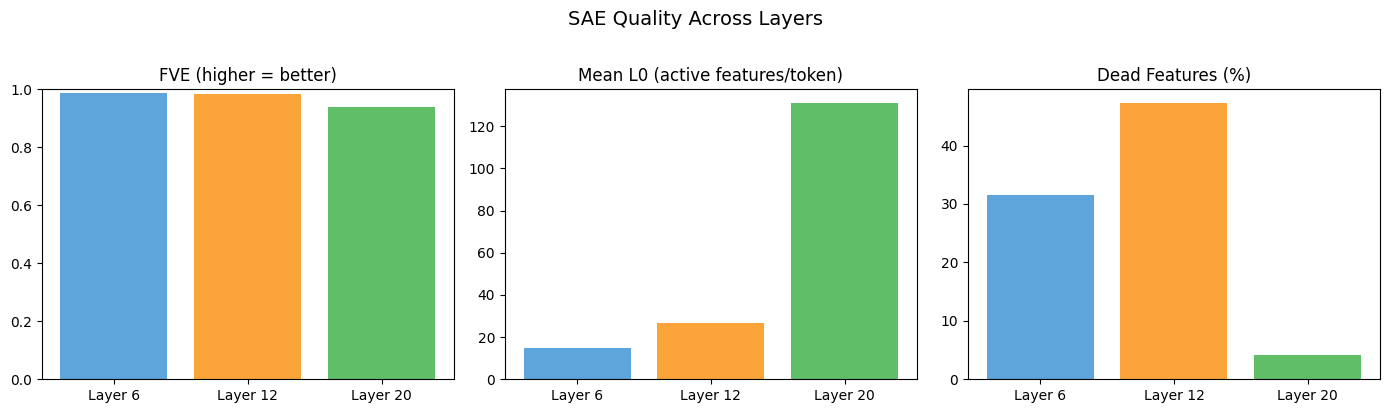


   Layer      FVE       L0    Dead%    Alive
--------------------------------------------
       6   0.9889     14.9     31.6    19610
      12   0.9831     26.6     47.3    15122
      20   0.9387    131.0      4.2    27470


In [161]:
import matplotlib.pyplot as plt

reports = [eval_report_6, eval_report_12, eval_report_20]
layers = [r["layer"] for r in reports]
fves = [r["fve"] for r in reports]
l0s = [r["mean_l0"] for r in reports]
dead_pcts = [r["dead_pct"] for r in reports]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(range(len(layers)), fves, tick_label=[f"Layer {l}" for l in layers], color=["#5DA5DA", "#FAA43A", "#60BD68"])
axes[0].set_title("FVE (higher = better)")
axes[0].set_ylim(0, 1)

axes[1].bar(range(len(layers)), l0s, tick_label=[f"Layer {l}" for l in layers], color=["#5DA5DA", "#FAA43A", "#60BD68"])
axes[1].set_title("Mean L0 (active features/token)")

axes[2].bar(range(len(layers)), dead_pcts, tick_label=[f"Layer {l}" for l in layers], color=["#5DA5DA", "#FAA43A", "#60BD68"])
axes[2].set_title("Dead Features (%)")

plt.suptitle("SAE Quality Across Layers", fontsize=14, y=1.02)
plt.tight_layout()

path = os.path.join(cfg.base_dir, "cross_layer_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print(f"\n{'Layer':>8} {'FVE':>8} {'L0':>8} {'Dead%':>8} {'Alive':>8}")
print("-" * 44)
for r in reports:
    print(f"{r['layer']:>8} {r['fve']:>8.4f} {r['mean_l0']:>8.1f} {r['dead_pct']:>8.1f} {r['alive_features']:>8}")

## 7. Save All Results

In [162]:
all_steering_results = []
for r in [result_pos_1, result_neg_1, result_pos_2, result_neg_2,
          result_brackets_pos, result_brackets_neg, result_the_pos, result_the_neg]:
    all_steering_results.append(r)

experiment_summary = {
    "config": {
        "model": cfg.model_name,
        "d_model": cfg.d_model,
        "d_sae": cfg.d_sae,
        "expansion": cfg.expansion_factor,
        "total_tokens": cfg.total_tokens,
        "l1_coeff": cfg.l1_coeff,
        "layers_tested": [6, 12, 20],
    },
    "evaluation_reports": {
        "layer_6": eval_report_6,
        "layer_12": eval_report_12,
        "layer_20": eval_report_20,
    },
    "steering_experiments": all_steering_results,
    "alpha_sweep": sweep_results,
}

results_path = os.path.join(cfg.base_dir, "full_experiment_results.json")
with open(results_path, "w") as f:
    json.dump(experiment_summary, f, indent=2, default=str)
print(f"All results saved to {results_path}")

if task:
    task.upload_artifact("Full_Experiment_Results", experiment_summary)
    task.close()
    print("Uploaded to ClearML.")

All results saved to ./experiments/full_experiment_results.json


## 8. Conclusions

### Reconstruction Quality

The trained SAE achieves strong reconstruction across all three layers, with FVE ranging from 0.939 (layer 20) to 0.989 (layer 6). This confirms that a sparse overcomplete dictionary with 32x expansion can capture the essential structure of the residual stream even when trained on a relatively modest 2M token budget. Notably, reconstruction quality decreases with depth: early layers are easier to reconstruct (FVE=0.989, L0≈15) while late layers require substantially more active features per token (L0≈131) and still achieve lower fidelity. This aligns with the intuition that later layers encode increasingly complex, distributed representations that are harder to decompose into a fixed-size sparse basis.

The dead feature percentages is interesting: layer 6 has 31.6% dead features, layer 12 has 47.3%, and layer 20 drops to just 4.2%. The low dead rate at layer 20 combined with high L0 suggests that the SAE is "using everything it has" but still struggling that is a sign that the 32x expansion factor may be insufficient for late layers, and a larger dictionary would likely improve both sparsity and reconstruction there.

### Monosemantic Features

Feature dictionaries across all three layers reveal that individual SAE features consistently activate on semantically coherent contexts. At layer 12, for example, feature #21836 fires reliably on percentage statistics ("45% of working Australians," "accounting for 18% of global output"), feature #3338 activates on direct speech attribution patterns ('said [Name],' 'says study co-author'), and feature #8966 captures the exemplification pattern ("such as X and Y"). Browsing the top 200 features for layer 12 reveals a consistent pattern where each feature corresponds to a recognizable linguistic or semantic concept.

However, the nature of captured features changes dramatically across layers. At layer 6, many top features encode surface-level patterns: feature #3046 fires on zeros in large numbers ("100,000"), feature #6785 activates on news wire headers ("(ANI):", "(Reuters)"), and feature #28659 captures the token "United" in geopolitical contexts. They capture token co-occurrence patterns rather than deep semantic concepts. At layer 20, the features become even more token-specific: most top features fire on particular subword prefixes ("Re-", "Ar-", "sp-", "con-"), suggesting that late layers use these directions for next-token prediction mechanics rather than abstract concept representation.

This progression from surface patterns (layer 6) through rich semantics (layer 12) to output-oriented token predictions (layer 20) is consistent with the established understanding of transformer layer roles and provides empirical support for the idea that middle layers are the most promising target for interpretability work.

### Activation Steering

The steering experiments provide the strongest evidence that the learned features are causally meaningful and not merely correlational artifacts.

**Feature #21836 (layer 12, "formal statistical reporting"):** When amplified at α=8.0, the model shifted from a philosophical discussion of life ("a journey that takes us through a series of experiences") to a dry enumeration of socioeconomic factors ("influenced by genetic, environmental, and social factors... influenced by factors of gender, race, and socioeconomic status"). The text became repetitive and report-like, looping through factor lists, in other words, the feature over-activating a "statistical fact". Negative steering (α=−8.0) produced the opposite: a structured, numbered list breaking life into categories (Physical, Emotional, Social), with no statistical claims whatsoever. The perplexity shift was modest (+0.16 for negative, +0.00 for positive), indicating that the intervention redirected content without catastrophically disrupting coherence.

**Feature #3338 (layer 12, "citation / attribution"):** This was the most dramatic steering result. At α=7.5, the model abandoned the topic entirely and generated pure dialogue attribution: '"I love the way he looks," says Sarah. "Am I right?" says John. "Am I right?" says Mary.' At α=10.0, the output became a cascade of "says Dr. Thomas" and "said Dr. Thomas" fragments and the model was essentially hallucinating a news article made entirely of quotes. Negative steering at α=−10.0 produced a different kind of degeneration: the model collapsed into a repetitive numbered list ("What is a Date Night? What is a Date Night?"), completely suppressing any attribution or voice. The alpha sweep on this feature clearly demonstrated the sweet spot: at moderate positive values (α=5.0), the model still produced coherent, on-topic text about clothing, but with a subtly more advisory tone. At extreme values, coherence collapsed in characteristic ways depending on direction.

**Layer 6 steering (feature #6785, "news wire format"):** The initial hypothesis was that this feature encodes parentheses/brackets, since it maximally activates on tokens like "(ANI):" and "(Reuters)". However, steering revealed something deeper: positive steering (α=7.0) shifted the text toward a casual, news-like tone with institutional references ("University of Wisconsin-Madison, the world leader in research"), while negative steering produced more structured, academic prose. The token a feature activates on is not necessarily what the feature means. The feature encodes an entire genre pattern (news wire text), of which parenthetical agency abbreviations are merely a surface marker. Early-layer features, it seems, capture holistic distributional patterns rather than isolated tokens.

**Layer 20 steering (features #16153 and #1259):** Steering at the late layer proved notably less effective. Feature #16153 ("The" at sentence boundaries) produced near-zero perplexity shift at α=±5.0 (+0.02 and +0.48), with only subtle changes in text structure. This is expected: by layer 20, the model is close to the output, and individual feature directions have less room to propagate through subsequent computation. Feature #1259 ("of course" / epistemic confidence marker) showed a more interesting pattern during alpha sweep: at α=10.0, the text degenerated into repetitive tautologies ("a subject in itself, a course in music... a crucial part of the humanities... a crucial part of the humanities"), while at α=−10.0 it became hedging and self-qualifying ("However, there is a deeper meaning... It is important to understand the cultural background"). The moderate values (α=±2.5 to ±5.0) produced the most interesting results, with positive steering making text more assertive and cliche-ridden, and negative steering making it more cautious and analytical.

### Cross-Layer Dynamics

The cross-layer comparison reveals a clear trade-off pattern in SAE behavior:

| Property | Layer 6 (early) | Layer 12 (middle) | Layer 20 (late) |
|----------|-----------------|-------------------|-----------------|
| FVE | 0.989 (best) | 0.983 | 0.939 (worst) |
| L0 | 14.9 (sparsest) | 26.6 | 131.0 (densest) |
| Dead features | 31.6% | 47.3% (most) | 4.2% (fewest) |
| Feature type | Surface/positional | Semantic/conceptual | Token-predictive |
| Steering effect | Genre-level shifts | Strong topical control | Weak / subtle |

Early layers are easy to reconstruct and produce sparse codes, but the features are shallow. Middle layers offer the richest interpretability and the most effective steering, at the cost of more dead features (likely because semantic concepts are sparser in the data than surface patterns). Late layers resist both sparse decomposition and causal intervention, consistent with their role in fine-grained next-token prediction.

### Limitations and Future Work

This project is a proof-of-concept, and several limitations should be acknowledged:

- **Data scale:** Training on 2M tokens is sufficient to demonstrate the pipeline, but production-grade SAEs train on billions of tokens. With more data, dead feature rates would likely decrease and feature quality would improve, especially at layer 12 where 47.3% of features are dead.
- **Dictionary size:** The 32x expansion factor (28,672 features for d_model=896) is moderate. Larger dictionaries (64x–256x) would likely capture finer-grained distinctions, such as separating "percentage statistics about health" from "percentage statistics about economics," which currently seem to be conflated in feature #21836.
- **Single-pass training:** The SAE sees each activation chunk only once. Multi-epoch training or curriculum strategies could improve feature quality, particularly for rare but interpretable concepts.
- **Interpretation methodology:** Feature labeling in this work is entirely manual and qualitative. Automated interpretation using an LLM-as-judge or using feature activation density plots would make the analysis more systematic and reproducible.
- **Steering on correct layer:** The steering experiments for layers 6 and 20 contain a subtle issue: the SAE was trained on one layer's activations, but the hook injection point in some experiments was set to a different layer.
- **Base model limitations:** Qwen2.5-0.5B is a relatively small model. Larger models with more layers and wider hidden states would likely produce more clearly differentiated features across layers, and the semantic richness of middle-layer features would be even more pronounced.

Despite these limitations, the results demonstrate that Sparse Autoencoders are a viable and practical tool for mechanistic interpretability. They can extract monosemantic features from polysemantic residual stream activations, and these features are not just statistically interesting, they are causally meaningful, as confirmed by activation steering experiments that produce predictable and interpretable changes in model behavior.